In [1]:
# ============================================================
# CELL 0 — env
# ============================================================
import warnings; warnings.filterwarnings("ignore")
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
!pip install pennylane pennylane-lightning --upgrade -q

import sys, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__} CUDA: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.1 MB/s eta 0:00:00
PyTorch: 2.10.0+cu128 CUDA: True


In [2]:
INPUT_DIR = "/kaggle/input/datasets/parthenaik/q-sentinel/Qsentinel"
OUTPUT_DIR = Path("/kaggle/working"); OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
scripts_dir = "/kaggle/input/datasets/parthenaik/my-cicio-scripts"
if scripts_dir not in sys.path: sys.path.append(scripts_dir)

import scripts
print("scripts loaded from:", scripts.__file__)

scripts loaded from: /kaggle/input/datasets/parthenaik/my-cicio-scripts/scripts/__init__.py


In [3]:
# ============================================================
# CELL 1 — scripts import
# ============================================================




from scripts.constants import (
    DEFAULT_EPOCHS, DEFAULT_LR, DEFAULT_BATCH_SIZE, DEFAULT_LAMBDA1, DEFAULT_LAMBDA2,
    DEFAULT_NOISE_RATE, DEFAULT_REUPLOAD, BARREN_PLATEAU_VAR_THRESHOLD, DEFAULT_N_TRIALS,
    DEFAULT_PATIENCE, DEFAULT_ALPHA, DEFAULT_CF, ZERO_DAY,
)
from scripts.data import (
    class_balance_table, capped_sample, stratified_head, plot_class_balance_bars,
    plot_class_balance_pie, greedy_kcenter_sample, greedy_dpp_sample,
    plot_dataset_and_sampling_analysis, load_split, to_angles,
)
from scripts.circuit import build_forward_circuit, create_quantum_device
from scripts.train import train_maqt
from scripts.utils import get_torch_device, to_np_y, to_np_batch_x
from scripts.logging import write_history_log
from scripts.memory import is_oom_error, run_batched_safely, safe_empty_cache
from scripts.prototypes import prototype_summary
from scripts.gradient import gradient_variance_probe
from scripts.theory import verify_fidelity_convention, estimate_lipschitz_percentile
from scripts.quantum_metrics import trace_distance
from scripts.hilbert import hilbert_geometry_diagnostics, print_h1_report
from scripts.sweep import run_sweep
from scripts.inference import predict_labels
from scripts.cache import (
    ForwardCache, cached_calibrate_threshold, cached_lipschitz_percentile,
    cached_qsnet_infer, cached_conformal_alpha_sweep, cached_predict_labels,
)
print("imports OK")

imports OK


In [4]:
# ============================================================
# CELL 2 — load splits (train/cal/test/zeroday)
# ============================================================
NOTEBOOK_NAME = "maqt-hptuned-cicio"
dataset = "CICIoT2023"
target_col = "label_multiclass"
DATA_DIR = f"/kaggle/input/datasets/parthenaik/q-sentinel-cicio/Qsentinel/CICIoT2023"
FROZEN_JSON_PATH = f"/kaggle/input/datasets/parthenaik/q-sentinel-cicio/Qsentinel/scripts/teamC_week3_FROZEN_handoff.json"

OUT_DIR = OUTPUT_DIR / "models" / "prototypes" / dataset; OUT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR = OUTPUT_DIR / "logs"; LOG_DIR.mkdir(parents=True, exist_ok=True)

handoff = json.loads(Path(FROZEN_JSON_PATH).read_text())
FEATURE_COLS = list(handoff["frozen_subsets"][dataset]["features"])
print(f"selector={handoff['frozen_subsets'][dataset]['selector']} k={len(FEATURE_COLS)}")

X_train_full, y_train_full, class_names, df_train = load_split(
    DATA_DIR, "train", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True)
X_cal_full, y_cal_full, _, df_cal = load_split(
    DATA_DIR, "calibration", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True)
X_test_full, y_test_full, _, df_test = load_split(
    DATA_DIR, "test", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True)
X_zero_full, y_zero_full, _, df_zero = load_split(
    DATA_DIR, "zeroday", target_col, csv=True, selected_cols=FEATURE_COLS, return_df=True)

print(f"train {X_train_full.shape} cal {X_cal_full.shape} test {X_test_full.shape} zero {X_zero_full.shape}")
print(f"classes: {class_names}")
num_classes = len(class_names)
# DDOS_ID = class_names.index("DDoS")
# DOS_ID = class_names.index("DoS")

selector=MI k=10
train (151049, 10) cal (18883, 10) test (18883, 10) zero (10984, 10)
classes: ['Backdoor_Malware', 'BenignTraffic', 'BrowserHijacking', 'CommandInjection', 'DDoS-ACK_Fragmentation', 'DDoS-HTTP_Flood', 'DDoS-ICMP_Flood', 'DDoS-ICMP_Fragmentation', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-SYN_Flood', 'DDoS-SlowLoris', 'DDoS-SynonymousIP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DDoS-UDP_Fragmentation', 'DNS_Spoofing', 'DictionaryBruteForce', 'DoS-HTTP_Flood', 'DoS-SYN_Flood', 'DoS-TCP_Flood', 'DoS-UDP_Flood', 'MITM-ArpSpoofing', 'Recon-HostDiscovery', 'Recon-OSScan', 'Recon-PingSweep', 'Recon-PortScan', 'SqlInjection', 'Uploading_Attack', 'VulnerabilityScan', 'XSS']


In [5]:
df_train.label_multiclass.value_counts()

label_multiclass
DDoS-ICMP_Flood            24202
DDoS-UDP_Flood             18146
DDoS-TCP_Flood             15141
DDoS-PSHACK_Flood          13700
DDoS-SYN_Flood             13653
DDoS-RSTFINFlood           13504
DDoS-SynonymousIP_Flood    12070
DoS-UDP_Flood              11098
DoS-TCP_Flood               8918
DoS-SYN_Flood               6797
BenignTraffic               3660
DDoS-ICMP_Fragmentation     1521
DoS-HTTP_Flood              1453
MITM-ArpSpoofing            1030
DDoS-UDP_Fragmentation       960
DDoS-ACK_Fragmentation       957
VulnerabilityScan            720
DNS_Spoofing                 606
DDoS-HTTP_Flood              561
DDoS-SlowLoris               493
Recon-HostDiscovery          463
Recon-OSScan                 331
Recon-PortScan               277
DictionaryBruteForce         230
BrowserHijacking             125
SqlInjection                 116
CommandInjection             106
Backdoor_Malware              75
XSS                           72
Recon-PingSweep           

In [6]:
# ============================================================
# CELL 3 — scale + PCA (fit on full train) + coreset + angles for ALL splits
# ============================================================
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)

USE_PCA, TARGET_VARIANCE = True, 0.95
pca_full = PCA(random_state=SEED).fit(X_train_full_scaled)
cum = np.cumsum(pca_full.explained_variance_ratio_)
k95 = min(int(np.searchsorted(cum, TARGET_VARIANCE) + 1), len(cum))
print(f"k95 components: {k95}")

pca = PCA(n_components=k95, random_state=SEED)
X_train_full_feat = pca.fit_transform(X_train_full_scaled)
x_min, x_max = X_train_full_feat.min(0), X_train_full_feat.max(0)

SUBSET, PER_CLASS_CAP = True, 1000
if SUBSET:
    X_train, y_train = greedy_dpp_sample(X_train_full, y_train_full, per_class_cap=PER_CLASS_CAP, seed=SEED)
else:
    X_train, y_train = X_train_full, y_train_full
print(f"train coreset: {X_train.shape}")

def _to_ang(X): return to_angles(X, scaler, x_min, x_max, pca=pca, angle_max=np.pi)

X_train_angles = _to_ang(X_train)
X_cal_angles   = _to_ang(X_cal_full)
X_test_angles  = _to_ang(X_test_full)
X_zero_angles  = _to_ang(X_zero_full)
print("angle shapes:", X_train_angles.shape, X_cal_angles.shape, X_test_angles.shape, X_zero_angles.shape)

k95 components: 6
train coreset: (20156, 10)
angle shapes: (20156, 6) (18883, 6) (18883, 6) (10984, 6)


In [7]:
# ============================================================
# CELL 4 — circuit + barren-plateau probe
# ============================================================
num_qubits = int(k95)
num_layers = 3
noise_rate = DEFAULT_NOISE_RATE
REUPLOAD = DEFAULT_REUPLOAD

device = get_torch_device()
dev = create_quantum_device(num_qubits)
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate, reupload=REUPLOAD)
print(f"device={device} wires={num_qubits}")

safe_empty_cache()
try:
    grad_var, _ = gradient_variance_probe(
        forward_circuit, X_train_angles[:1], num_qubits, num_layers,
        n_trials=5, device=torch.device("cpu"),
    )
    print(f"pre-train grad var = {grad_var:.2e} (thr={BARREN_PLATEAU_VAR_THRESHOLD:.0e})")
except RuntimeError as e:
    if is_oom_error(e): safe_empty_cache()
    else: raise

device=cuda wires=6
pre-train grad var = 5.44e-10 (thr=1e-06)


In [8]:
# ============================================================
# IMPORTANT: run Cells 0–4 first (env, imports, data load/PCA/coreset,
# circuit + barren-plateau probe) EXACTLY as before, same SEED=42,
# same DATA_DIR / FROZEN_JSON_PATH, same num_qubits/num_layers.
# This rebuilds scaler, pca, x_min/x_max, forward_circuit, theta shape
# etc. identically — required before resuming, since Kaggle wiped state.
# ============================================================

# ============================================================
# CELL 8-RESUME — continue training from epoch 11 -> 15
# ============================================================
epochs = 15                 # <-- target total epoch count (was 30)
batch_size = 8
lambda1 = 0.5
lambda2 = 0.66
lr = 0.005
early_stopping = True
patience = 5
min_delta = 0.001

ckpt_dir = OUT_DIR / f"{NOTEBOOK_NAME}_seed{SEED}"
ckpt_dir.mkdir(parents=True, exist_ok=True)

# point this at your saved epoch-11 checkpoint (numbered file is safest,
# since -latest.pt could also be a mid-epoch save from step-based checkpointing)
resume_from = Path("/kaggle/input/models/parthenaik/cicio3-retraining-model/other/default/1/maqt-latest.pt")
if not resume_from.exists():
    resume_from = ckpt_dir / "maqt-latest.pt"   # fallback
assert resume_from.exists(), f"checkpoint not found: {resume_from}"
print(f"resuming from: {resume_from}")

torch.manual_seed(SEED)
result = run_batched_safely(
    train_maqt, X_train_angles, y_train,
    n_classes=num_classes, n_qubits=num_qubits, n_layers=num_layers,
    forward_circuit=forward_circuit, device=device,
    epochs=epochs, lr=lr, batch_size=batch_size, min_batch=2,
    label="train_maqt",
    lambda1_max=lambda1, lambda2_max=lambda2,
    use_weighted_sampler=True, seed=SEED,
    early_stopping=early_stopping, patience=patience, min_delta=min_delta,
    checkpoint_dir=ckpt_dir, save_every_epoch=True,
    resume_from=resume_from,
    reset_early_stopping_on_resume=True,     # fresh patience window for this leg
    heartbeat_every_steps=50, notebook_name=NOTEBOOK_NAME, log_dir=ckpt_dir,
)
if result is None:
    raise RuntimeError("train_maqt failed even at min_batch (OOM)")

theta_star, classifier_head, prototypes, ema_protos, history = result
safe_empty_cache()
print(f"epochs_ran={history.get('epochs_ran')} best_epoch={history.get('best_epoch')} "
      f"stop_reason={history.get('stop_reason')}")

resuming from: /kaggle/input/models/parthenaik/cicio3-retraining-model/other/default/1/maqt-latest.pt
resumed MAQT from /kaggle/input/models/parthenaik/cicio3-retraining-model/other/default/1/maqt-latest.pt at epoch 11, step 200 (mid-epoch) / 15
(patience reset)
	epoch 12 step 250 (10%) loss=1.3831 elapsed=79s eta=721s
	epoch 12 step 300 (12%) loss=1.7743 elapsed=156s eta=1156s
	epoch 12 step 350 (14%) loss=2.4214 elapsed=233s eta=1445s
	epoch 12 step 400 (16%) loss=1.4114 elapsed=310s eta=1642s
	epoch 12 step 450 (18%) loss=0.9826 elapsed=387s eta=1779s
	epoch 12 step 500 (20%) loss=1.6036 elapsed=464s eta=1873s
	epoch 12 step 550 (22%) loss=1.9682 elapsed=541s eta=1936s
	epoch 12 step 600 (24%) loss=2.2044 elapsed=617s eta=1975s
	epoch 12 step 650 (26%) loss=1.2862 elapsed=694s eta=1997s
	epoch 12 step 700 (28%) loss=1.8566 elapsed=771s eta=2004s
	epoch 12 step 750 (30%) loss=1.7634 elapsed=848s eta=2000s
	epoch 12 step 800 (32%) loss=2.2127 elapsed=925s eta=1987s
	epoch 12 step 850 

In [9]:
# ============================================================
# CELL 9 — save best model
# ============================================================
ckpt_path = OUT_DIR / f"{NOTEBOOK_NAME}-checkpoint.pt"
torch.save({
    "theta": theta_star.detach().cpu(),
    "head_state_dict": classifier_head.state_dict(),
    "prototypes": {k: v.detach().cpu() for k, v in prototypes.items()},
    "class_names": list(class_names),
    "num_classes": num_classes, "num_qubits": num_qubits, "num_layers": num_layers,
    "noise_rate": noise_rate, "reupload": REUPLOAD, "feature_cols": list(FEATURE_COLS),
    "lambda1": lambda1, "lambda2": lambda2, "lr": lr,
    "scaler": scaler, "pca": pca, "k95": int(k95),
    "angle_x_min": np.asarray(x_min), "angle_x_max": np.asarray(x_max),
    "angle_min": 0.0, "angle_max": float(np.pi),
}, ckpt_path)
print("published:", ckpt_path.resolve())

proto_df = pd.DataFrame(prototype_summary(prototypes, class_names))
proto_df

published: /kaggle/working/models/prototypes/CICIoT2023/maqt-hptuned-cicio-checkpoint.pt


,class,dim,trace
0,Backdoor_Malware,64,1.000001
1,BenignTraffic,64,1.000001
2,BrowserHijacking,64,1.000001
3,CommandInjection,64,1.000001
4,DDoS-ACK_Fragmentation,64,1.000001
5,DDoS-HTTP_Flood,64,1.000001
6,DDoS-ICMP_Flood,64,1.000001
7,DDoS-ICMP_Fragmentation,64,1.000001
8,DDoS-PSHACK_Flood,64,1.000001
9,DDoS-RSTFINFlood,64,1.000001


test accuracy: 0.7095

                         precision    recall  f1-score   support

       Backdoor_Malware       0.04      0.33      0.06         9
          BenignTraffic       0.64      0.33      0.44       458
       BrowserHijacking       0.00      0.00      0.00        16
       CommandInjection       0.02      0.08      0.03        13
 DDoS-ACK_Fragmentation       0.81      0.79      0.80       120
        DDoS-HTTP_Flood       0.12      0.51      0.19        70
        DDoS-ICMP_Flood       0.83      0.98      0.90      3025
DDoS-ICMP_Fragmentation       0.88      0.95      0.92       190
      DDoS-PSHACK_Flood       0.79      0.83      0.81      1712
       DDoS-RSTFINFlood       0.90      0.76      0.82      1688
         DDoS-SYN_Flood       0.59      0.93      0.72      1706
         DDoS-SlowLoris       0.27      0.35      0.30        62
DDoS-SynonymousIP_Flood       0.92      0.36      0.52      1509
         DDoS-TCP_Flood       0.76      0.80      0.78      1892
 

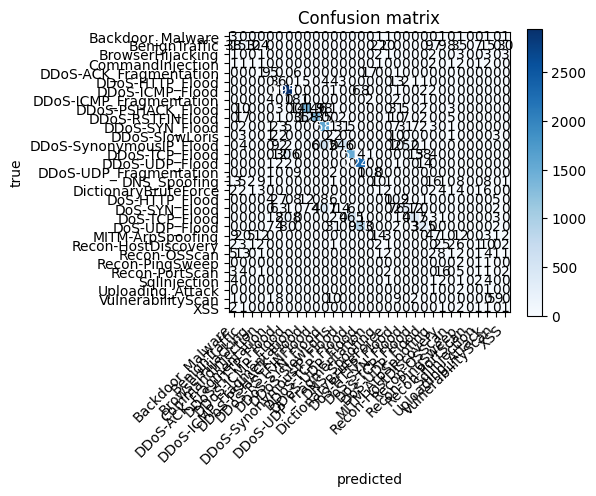

In [10]:
# ============================================================
# CELL 10 — accuracy + confusion matrix (focus on DDoS/DoS)
# ============================================================
y_true, y_pred = predict_labels(X_test_angles, y_test_full, theta_star, classifier_head,
                                 forward_circuit, device=device, batch_size=DEFAULT_BATCH_SIZE)
acc = accuracy_score(y_true, y_pred)
print(f"test accuracy: {acc:.4f}\n")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(num_classes)); ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticks(range(num_classes)); ax.set_yticklabels(class_names)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix")
plt.colorbar(im); plt.tight_layout(); plt.show()



In [11]:
# ============================================================
# CELL 11 — H1 Hilbert-geometry diagnostics
# ============================================================
h1_report = hilbert_geometry_diagnostics(
    theta_star, X_test_angles, y_test_full, prototypes, forward_circuit,
    class_names=class_names, device=device, max_per_class=2000, seed=SEED,
)
print_h1_report(h1_report)



=== H1 Hilbert geometry (fidelity gaps) ===
mean intra-class fidelity : 0.7802
mean inter-class fidelity : 0.6233
fidelity gap (intra-inter): 0.1569  ← want ↑
mean inter trace distance : 0.6717  ← want ↑

per-class intra fidelity:
  Backdoor_Malware             n=   9  F=0.6264
  BenignTraffic                n= 458  F=0.6656
  BrowserHijacking             n=  16  F=0.6006
  CommandInjection             n=  13  F=0.5985
  DDoS-ACK_Fragmentation       n= 120  F=0.9394
  DDoS-HTTP_Flood              n=  70  F=0.8479
  DDoS-ICMP_Flood              n=2000  F=0.9789
  DDoS-ICMP_Fragmentation      n= 190  F=0.9602
  DDoS-PSHACK_Flood            n=1712  F=0.9406
  DDoS-RSTFINFlood             n=1688  F=0.9395
  DDoS-SYN_Flood               n=1706  F=0.9316
  DDoS-SlowLoris               n=  62  F=0.8025
  DDoS-SynonymousIP_Flood      n=1509  F=0.9410
  DDoS-TCP_Flood               n=1892  F=0.9394
  DDoS-UDP_Flood               n=2000  F=0.9925
  DDoS-UDP_Fragmentation       n= 120  F=0.9558
 

In [12]:
# ============================================================
# CELL 12 — zero-day / conformal (CQ-ZDR) evaluation
# ============================================================
cache = ForwardCache(store_device="cpu")
entry_cal   = cache.compute("cal",   X_cal_angles,  theta_star, forward_circuit, device=device, batch_size=64)
entry_test  = cache.compute("test",  X_test_angles, theta_star, forward_circuit, device=device, batch_size=64)
entry_zero  = cache.compute("zero",  X_zero_angles, theta_star, forward_circuit, device=device, batch_size=64)

# 1) calibrate conformal threshold q from calibration split
q, scores_sorted = cached_calibrate_threshold(entry_cal, prototypes, alpha=DEFAULT_ALPHA)
print(f"conformal threshold q = {q:.4f} (alpha={DEFAULT_ALPHA}, n_cal={len(scores_sorted)})")

# 2) Lipschitz percentile estimate (for certified radius)
lip = cached_lipschitz_percentile(entry_test, n_pairs=300, percentile=95)
L_phi = lip["p95"]
print(f"L_phi (p95) = {L_phi:.4f}  max_ratio={lip['max']:.4f}")

# 3) unified inference on KNOWN test set
labels_test, radii_test, scores_test, _ = cached_qsnet_infer(
    entry_test, prototypes, q, p=noise_rate, L_phi=L_phi, Cf=DEFAULT_CF, device=device,
)
known_mask = labels_test != ZERO_DAY
known_acc = float(np.mean(labels_test[known_mask] == to_np_y(y_test_full).astype(int)[known_mask])) if known_mask.any() else float("nan")
reject_rate_known = float(np.mean(~known_mask))
print(f"known-test accuracy (non-rejected): {known_acc:.4f}")
print(f"false-alarm (known flagged as zero-day): {reject_rate_known:.4f}")

# 4) unified inference on ZERO-DAY set
labels_zero, radii_zero, scores_zero, _ = cached_qsnet_infer(
    entry_zero, prototypes, q, p=noise_rate, L_phi=L_phi, Cf=DEFAULT_CF, device=device,
)
zero_day_detection_rate = float(np.mean(labels_zero == ZERO_DAY))
print(f"zero-day detection rate: {zero_day_detection_rate:.4f}  (n={len(labels_zero)})")

# 5) alpha sweep (how the false-alarm rate tracks target alpha)
alpha_sweep_rows = cached_conformal_alpha_sweep(entry_cal, entry_test, prototypes,
                                                 alphas=(0.01, 0.05, 0.1, 0.2))
pd.DataFrame(alpha_sweep_rows)

conformal threshold q = 0.2425 (alpha=0.05, n_cal=18883)
L_phi (p95) = 0.7948  max_ratio=0.8653
known-test accuracy (non-rejected): 0.7028
false-alarm (known flagged as zero-day): 0.0490
zero-day detection rate: 0.0087  (n=10984)


,alpha,q,empirical_false_alarm_rate,min_calibration_size,n_cal
0,0.01,0.367036,0.010697,99.0,18883
1,0.05,0.242506,0.049039,19.0,18883
2,0.10,0.156824,0.101255,9.0,18883
3,0.20,0.064647,0.203463,4.0,18883


In [13]:
# ============================================================
# CELL 13 — log everything
# ============================================================
log_path = write_history_log(
    history, NOTEBOOK_NAME,
    extra={
        "best_lambda2": BEST_LAMBDA2, "best_lr": BEST_LR,
        "sweep_grid": {"lambda2": LAMBDA2_GRID, "lr": LR_GRID},
        "test_accuracy": acc, "ddos_dos_confusion": int(ddos_dos_confusion),
        "h1_fidelity_gap": h1_report["fidelity_gap"],
        "conformal_q": float(q), "L_phi_p95": float(L_phi),
        "known_test_accuracy_nonrejected": known_acc,
        "zero_day_detection_rate": zero_day_detection_rate,
        "class_names": list(class_names), "seed": SEED,
    },
    log_dir=str(LOG_DIR),
)
print(f"wrote {Path(log_path).resolve()}")

NameError: name 'BEST_LAMBDA2' is not defined